# ALM Toolkit — Core Library

This notebook demonstrates the three foundational modules of the toolkit, built bottom-up:

1. **Yield curve & discounting** (`core.curve`) — converting future money into present value.
2. **Cash flows & pricing** (`core.cashflow`) — representing and valuing streams of dated payments.
3. **Risk measures** (`core.risk`) — duration and convexity, the sensitivity of value to interest rates.

Each builds on the previous one. The application layer (immunization) is shown in `02_immunization.ipynb`.

本 notebook 由下而上展示工具組的三個基礎模組：殖利率曲線與折現、現金流與定價、風險指標（存續期間與凸度）。每一層都建立在前一層之上；應用層（免疫化）見 `02_immunization.ipynb`。

In [4]:
"""
為什麼要那行 sys.path.insert？
因為 notebook 放在 notebooks/ 資料夾裡執行，而我們的程式庫在 src/alm/。
Python 預設不知道去 src/ 找套件，所以我們手動把 src/ 加進搜尋路徑。
Path.cwd().parent / "src" 的意思是「目前資料夾（notebooks）的上一層、再進到 src」——用相對路徑而非寫死絕對路徑，
這樣別人 clone 你的 repo 在他自己的機器上也能跑，維持可重現性。
"""

import sys
from pathlib import Path

# Make the toolkit importable: add the project's src/ directory to sys.path.
# (The notebook lives in notebooks/, so src/ is one level up.)
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from alm.core.curve import YieldCurve
from alm.core.cashflow import CashFlow
from alm.core.risk import (
    present_value_at_yield,
    macaulay_duration,
    convexity,
)

# Cleaner default plot style.
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

## 1. Yield Curve & Discounting

A yield curve maps each maturity to a zero rate. Its core job is to produce a **discount factor** for any time *t*, turning future money into present value via `DF(t) = exp(-r(t)·t)` (continuous compounding). Everything else in the toolkit builds on this.

殖利率曲線將每個期限對應到一個零息利率。它的核心工作是為任意時間 *t* 產生**折現因子**，透過 `DF(t) = exp(-r(t)·t)`（連續複利）把未來的錢換算成現值。工具組的其他一切都建立在此之上。

In [5]:
# Build an upward-sloping yield curve from a few market tenor points.
curve = YieldCurve(tenors=[1, 2, 5, 10, 30], rates=[0.030, 0.033, 0.037, 0.040, 0.042])

# The curve answers two questions for any tenor:
for t in [3, 7, 20]:
    print(f"t={t:>2}y   zero rate = {curve.zero_rate(t):.4f}   "
          f"discount factor = {curve.discount_factor(t):.4f}")

t= 3y   zero rate = 0.0343   discount factor = 0.9021
t= 7y   zero rate = 0.0382   discount factor = 0.7654
t=20y   zero rate = 0.0410   discount factor = 0.4404


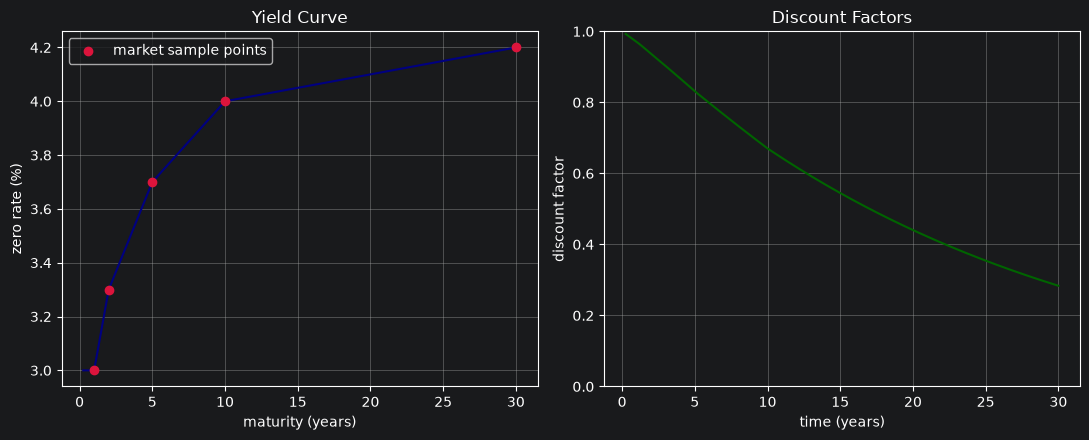

In [6]:
# Plot the yield curve and the discount factor curve side by side.
ts = np.linspace(0.25, 30, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: the zero-rate curve, with the original sample points marked.
ax1.plot(ts, curve.zero_rate(ts) * 100, color="navy")
ax1.scatter(curve.tenors, curve.rates * 100, color="crimson", zorder=5,
            label="market sample points")
ax1.set_xlabel("maturity (years)")
ax1.set_ylabel("zero rate (%)")
ax1.set_title("Yield Curve")
ax1.legend()

# Right: discount factors decaying toward zero as horizon grows.
ax2.plot(ts, curve.discount_factor(ts), color="darkgreen")
ax2.set_xlabel("time (years)")
ax2.set_ylabel("discount factor")
ax2.set_title("Discount Factors")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 2. Cash Flows & Pricing

Real instruments are *streams* of dated payments. A coupon bond pays periodic coupons plus principal at maturity; a liability is a stream of future obligations. A `CashFlow` represents any such stream, and its present value is the sum of each payment discounted by the curve.

真實的金融工具是一連串帶日期的給付。附息債券定期支付票息、到期償還本金；負債則是一連串未來義務。`CashFlow` 表達任何這類現金流，其現值是各筆給付經曲線折現後的加總。

In [7]:
# A 5-year bond, 4% annual coupon on 100 face value:
# coupons of 4 at t=1..5, plus the 100 principal repaid at t=5.
times = [1, 2, 3, 4, 5]
amounts = [4, 4, 4, 4, 4 + 100]

bond = CashFlow(times=times, amounts=amounts)

price = bond.present_value(curve)
print(f"Bond price (PV under the curve): {price:.4f}")
print(f"Sum of undiscounted cash flows:  {sum(amounts):.4f}")
print(f"Discount effect:                 {sum(amounts) - price:.4f}")

Bond price (PV under the curve): 101.1378
Sum of undiscounted cash flows:  120.0000
Discount effect:                 18.8622


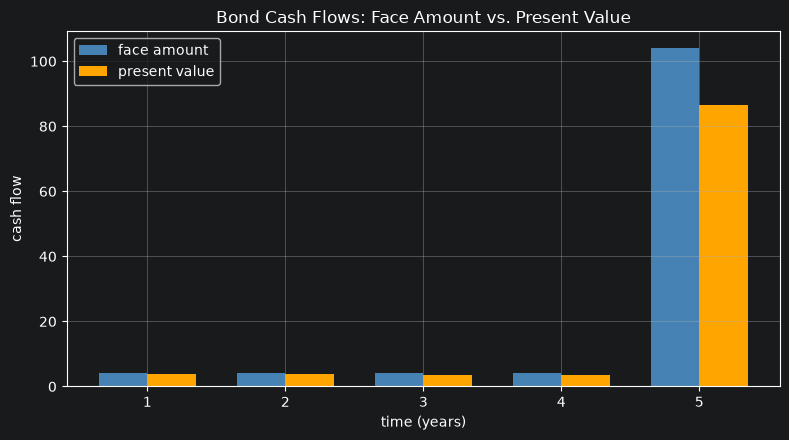

In [8]:
# Visualize each cash flow at face value vs. its present value.
pvs = bond.amounts * curve.discount_factor(bond.times)

fig, ax = plt.subplots()
width = 0.35
ax.bar(bond.times - width/2, bond.amounts, width,
       label="face amount", color="steelblue")
ax.bar(bond.times + width/2, pvs, width,
       label="present value", color="orange")

ax.set_xlabel("time (years)")
ax.set_ylabel("cash flow")
ax.set_title("Bond Cash Flows: Face Amount vs. Present Value")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Risk Measures: Duration & Convexity

How does a bond's value respond to interest rates? **Duration** is the first-order sensitivity — the slope of the price-yield curve. **Convexity** is the second-order term — its curvature. Together they form a Taylor expansion of price around the current yield: duration gives the tangent line, and convexity explains why the true curve bends away from that line.

債券價值如何隨利率變動？**存續期間**是一階敏感度——價格-殖利率曲線的斜率。**凸度**是二階項——它的曲率。兩者構成價格在當前殖利率附近的泰勒展開：存續期間給出切線，凸度則解釋了真實曲線為何偏離該切線。

In [9]:
# Compute the bond's risk measures at a flat yield y.
y = 0.04

pv0 = present_value_at_yield(bond, y)
dur = macaulay_duration(bond, y)
conv = convexity(bond, y)

print(f"At yield y = {y:.2%}")
print(f"  Price (PV)          : {pv0:.4f}")
print(f"  Macaulay duration   : {dur:.4f} years")
print(f"  Convexity           : {conv:.4f}")

At yield y = 4.00%
  Price (PV)          : 99.6399
  Macaulay duration   : 4.6291 years
  Convexity           : 22.4185


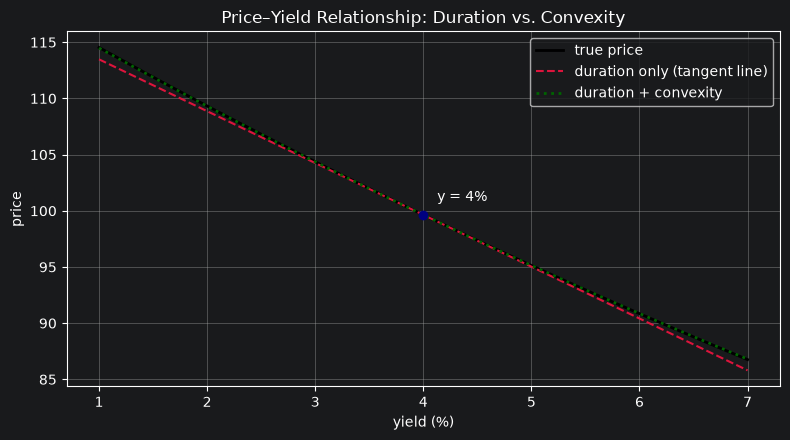

In [10]:
# The geometry of duration and convexity.
# True price as a function of yield, vs. the duration (linear) and
# duration+convexity (quadratic) approximations around y.
ys = np.linspace(y - 0.03, y + 0.03, 200)
true_prices = np.array([present_value_at_yield(bond, yi) for yi in ys])

dy = ys - y
# First-order (duration only): P ≈ P0 * (1 - D * dy)
approx_duration = pv0 * (1 - dur * dy)
# Second-order (add convexity): P ≈ P0 * (1 - D*dy + 0.5*C*dy^2)
approx_convexity = pv0 * (1 - dur * dy + 0.5 * conv * dy**2)

fig, ax = plt.subplots()
ax.plot(ys * 100, true_prices, color="black", lw=2, label="true price")
ax.plot(ys * 100, approx_duration, "--", color="crimson",
        label="duration only (tangent line)")
ax.plot(ys * 100, approx_convexity, ":", color="darkgreen", lw=2,
        label="duration + convexity")
ax.scatter([y * 100], [pv0], color="navy", zorder=5)
ax.annotate(f"y = {y:.0%}", (y * 100, pv0),
            textcoords="offset points", xytext=(10, 10))

ax.set_xlabel("yield (%)")
ax.set_ylabel("price")
ax.set_title("Price–Yield Relationship: Duration vs. Convexity")
ax.legend()

plt.tight_layout()
plt.show()

---

These three layers — curve, cash flow, risk — are the foundation. In **`02_immunization.ipynb`**, they come together to solve a real ALM problem: building a bond portfolio whose value tracks a liability as rates move, using the duration and convexity measures developed here.

這三層——曲線、現金流、風險——構成了基礎。在 **`02_immunization.ipynb`** 中，它們將匯聚起來解決一個真實的 ALM 問題：運用此處發展的存續期間與凸度指標，建構一個價值能隨利率變動追蹤負債的債券組合。